<a href="https://colab.research.google.com/github/Maynul-sabuj/CodeAlpha_CreditScoringModel/blob/main/Credit_Scoring_Model_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scoring Model — CodeAlpha Machine Learning Internship (Task 1)

Single-file, Colab-ready notebook. Predicts whether an individual is a
**good** or **bad** credit risk from financial-history features, and
compares Logistic Regression, Decision Tree, and Random Forest
classifiers using Precision, Recall, F1-score, and ROC-AUC.

**Run all cells top to bottom** — no external files needed; the dataset
is generated inside this notebook.

## 0. Setup

Everything needed (pandas, scikit-learn, matplotlib, seaborn, joblib)
is already installed in Colab — no pip installs required.

In [1]:
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
TARGET_COL = "creditworthy"

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

## 1. Generate the Dataset

Real credit-scoring datasets (e.g. the UCI/Statlog German Credit
dataset) require an external download. Instead, this cell **generates
a realistic synthetic dataset** of 5,000 loan applicants, with features
that follow real underwriting logic (income, existing debt,
debt-to-income ratio, late payments, credit utilization, etc.) combined
through a logistic risk formula plus noise — so the classification task
behaves like a genuine credit-risk problem (~74% good / 26% bad, similar
to the real German Credit dataset's ~70/30 split), not a trivially easy
one.

**To use a real dataset instead:** load your own CSV with the same
columns and a `creditworthy` target (1 = good risk, 0 = bad risk) in
place of the generated DataFrame below — everything downstream works
unchanged.

In [2]:
def generate_credit_dataset(n_samples=5000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    age = rng.integers(19, 70, n_samples)
    annual_income = rng.gamma(shape=6, scale=8000, size=n_samples) + 12000
    employment_length_years = np.clip(rng.normal(7, 5, n_samples), 0, 40)

    existing_debt = np.clip(annual_income * rng.uniform(0.02, 0.55, n_samples), 0, None)
    debt_to_income_ratio = existing_debt / annual_income

    num_credit_lines = rng.integers(0, 12, n_samples)
    num_late_payments_2yrs = rng.poisson(lam=np.clip(1.2 - annual_income / 100000, 0.05, None))
    num_late_payments_2yrs = np.clip(num_late_payments_2yrs, 0, 12)

    credit_utilization = np.clip(rng.beta(2, 3, n_samples), 0, 1)
    savings_balance = np.clip(rng.gamma(2, annual_income / 20, n_samples), 0, None)
    checking_balance = np.clip(rng.normal(annual_income / 15, annual_income / 20, n_samples), 0, None)

    loan_amount = np.clip(rng.gamma(3, 3000, n_samples), 500, 60000)
    loan_term_months = rng.choice([12, 24, 36, 48, 60], n_samples)

    has_bankruptcy = rng.binomial(1, 0.05, n_samples)
    home_ownership = rng.choice(["own", "mortgage", "rent"], n_samples, p=[0.25, 0.35, 0.40])
    purpose = rng.choice(
        ["car", "education", "home_improvement", "medical", "business", "debt_consolidation"], n_samples
    )

    credit_history_years = np.clip(age - rng.integers(18, 26, n_samples), 0, None)

    # Underwriting-style latent "risk score" (higher = safer)
    risk_score = (
        1.15
        - 3.0 * debt_to_income_ratio
        - 0.35 * num_late_payments_2yrs
        - 2.2 * credit_utilization
        + 0.05 * credit_history_years
        + 0.00002 * annual_income
        + 0.02 * employment_length_years
        + 0.00001 * savings_balance
        - 1.6 * has_bankruptcy
        - 0.00003 * loan_amount
        + rng.normal(0, 0.6, n_samples)  # noise so the problem isn't trivially separable
    )
    prob_good = 1 / (1 + np.exp(-risk_score))
    creditworthy = rng.binomial(1, prob_good)

    return pd.DataFrame({
        "age": age,
        "annual_income": annual_income.round(2),
        "employment_length_years": employment_length_years.round(1),
        "existing_debt": existing_debt.round(2),
        "debt_to_income_ratio": debt_to_income_ratio.round(3),
        "num_credit_lines": num_credit_lines,
        "num_late_payments_2yrs": num_late_payments_2yrs,
        "credit_utilization": credit_utilization.round(3),
        "savings_balance": savings_balance.round(2),
        "checking_balance": checking_balance.round(2),
        "loan_amount": loan_amount.round(2),
        "loan_term_months": loan_term_months,
        "credit_history_years": credit_history_years,
        "has_bankruptcy": has_bankruptcy,
        "home_ownership": home_ownership,
        "purpose": purpose,
        "creditworthy": creditworthy,
    })


df = generate_credit_dataset()
df.to_csv("data/credit_data.csv", index=False)
print(df.shape)
df.head()

(5000, 17)


,age,annual_income,employment_length_years,existing_debt,debt_to_income_ratio,num_credit_lines,num_late_payments_2yrs,credit_utilization,savings_balance,checking_balance,loan_amount,loan_term_months,credit_history_years,has_bankruptcy,home_ownership,purpose,creditworthy
0,23,50541.47,10.7,6701.41,0.133,1,3,0.009,2604.85,113.96,21433.83,36,3,0,rent,home_improvement,1
1,58,73610.79,0.0,32000.76,0.435,3,0,0.344,9086.34,0.00,9758.69,60,34,0,own,home_improvement,1
2,52,47887.68,2.4,22816.75,0.476,4,0,0.475,1809.03,2269.66,5603.66,12,34,0,rent,debt_consolidation,1
3,41,68439.11,9.7,33166.94,0.485,5,1,0.647,10574.30,9040.34,11566.32,36,17,0,rent,debt_consolidation,1
4,41,49956.03,3.9,13594.57,0.272,2,0,0.115,1725.76,0.00,8112.98,60,16,0,rent,medical,1


In [3]:
df["creditworthy"].value_counts(normalize=True).rename("class balance")

,class balance
creditworthy,
1,0.7374
0,0.2626


## 2. Quick Exploratory Look

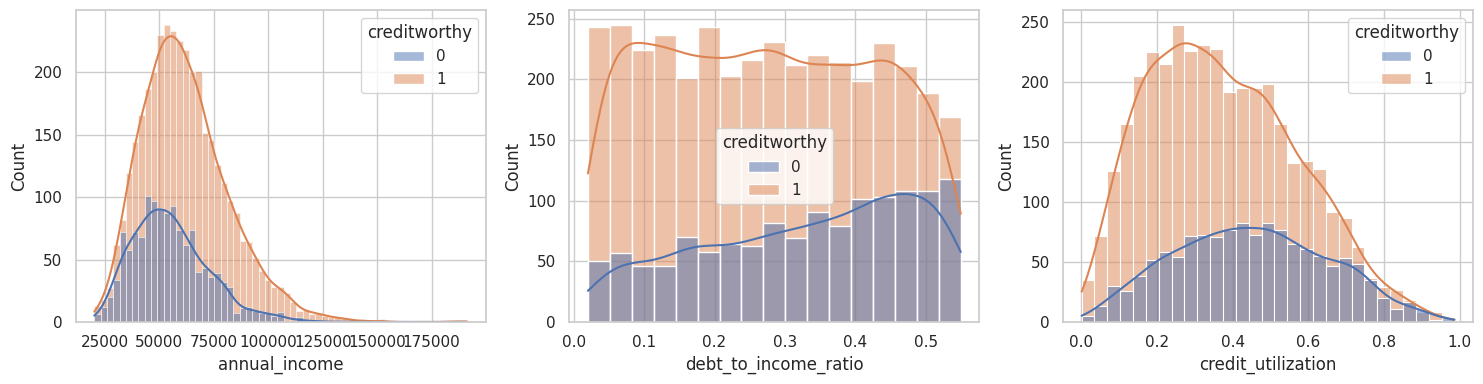

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df, x="annual_income", hue="creditworthy", kde=True, ax=axes[0])
sns.histplot(data=df, x="debt_to_income_ratio", hue="creditworthy", kde=True, ax=axes[1])
sns.histplot(data=df, x="credit_utilization", hue="creditworthy", kde=True, ax=axes[2])
plt.tight_layout()
plt.show()

## 3. Preprocessing

Numeric features are scaled; categorical features are one-hot encoded.
Both live inside a single `sklearn.Pipeline` together with the
classifier, so there's no risk of leaking test-set information into
training.

In [5]:
numeric_features = df.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric features (14): ['age', 'annual_income', 'employment_length_years', 'existing_debt', 'debt_to_income_ratio', 'num_credit_lines', 'num_late_payments_2yrs', 'credit_utilization', 'savings_balance', 'checking_balance', 'loan_amount', 'loan_term_months', 'credit_history_years', 'has_bankruptcy']
Categorical features (2): ['home_ownership', 'purpose']
Train: (4000, 16), Test: (1000, 16)


## 4. Train Models

We compare three classic classification algorithms, as specified in the
task brief.

In [6]:
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1),
}

all_metrics = []
fitted_pipelines = {}

for name, model in models_dict.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    all_metrics.append(metrics)

    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=["Bad Risk (0)", "Good Risk (1)"]))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv("outputs/model_metrics.csv", index=False)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
metrics_df.set_index("model").round(4)


Logistic Regression
               precision    recall  f1-score   support

 Bad Risk (0)       0.62      0.32      0.42       263
Good Risk (1)       0.79      0.93      0.86       737

     accuracy                           0.77      1000
    macro avg       0.71      0.62      0.64      1000
 weighted avg       0.75      0.77      0.74      1000

ROC-AUC: 0.7682

Decision Tree
               precision    recall  f1-score   support

 Bad Risk (0)       0.54      0.22      0.31       263
Good Risk (1)       0.77      0.93      0.84       737

     accuracy                           0.74      1000
    macro avg       0.65      0.58      0.58      1000
 weighted avg       0.71      0.74      0.70      1000

ROC-AUC: 0.6763

Random Forest
               precision    recall  f1-score   support

 Bad Risk (0)       0.65      0.19      0.30       263
Good Risk (1)       0.77      0.96      0.86       737

     accuracy                           0.76      1000
    macro avg       0.71     

,precision,recall,f1_score,roc_auc
model,,,,
Logistic Regression,0.7928,0.9294,0.8557,0.7682
Decision Tree,0.7696,0.9335,0.8437,0.6763
Random Forest,0.7701,0.9634,0.8559,0.7607


## 5. Compare Models

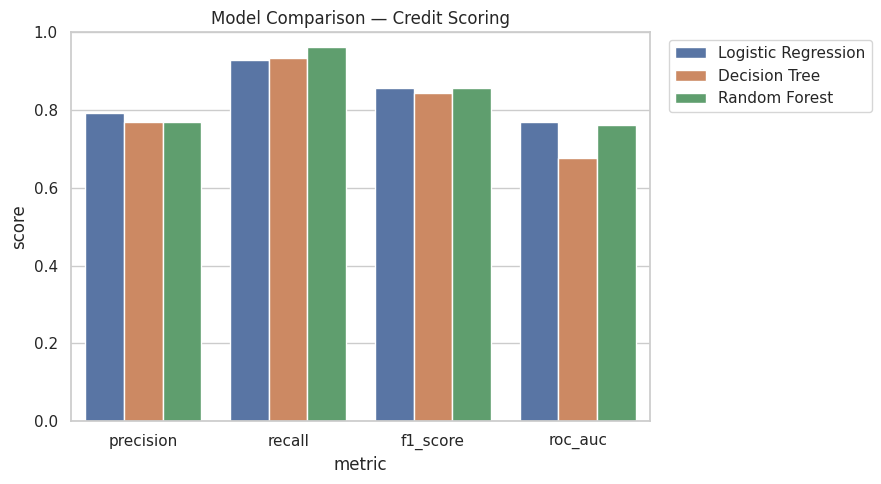

In [7]:
plot_df = metrics_df.melt(id_vars="model", var_name="metric", value_name="score")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Model Comparison — Credit Scoring")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()

## 6. Confusion Matrices & ROC Curves

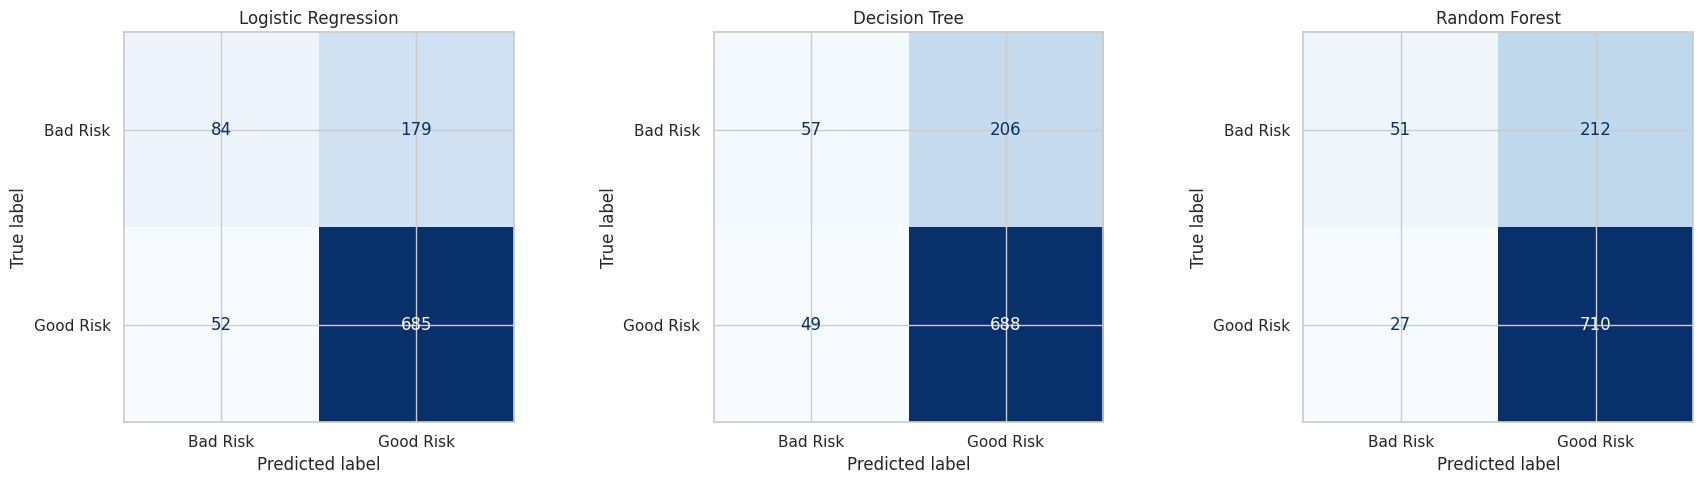

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipeline) in zip(axes, fitted_pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test, display_labels=["Bad Risk", "Good Risk"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", dpi=150)
plt.show()

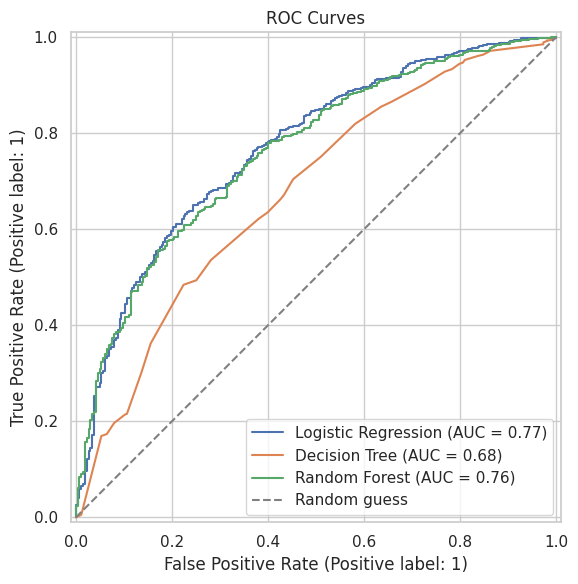

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipeline in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curves.png", dpi=150)
plt.show()

## 7. Feature Importance (Random Forest)

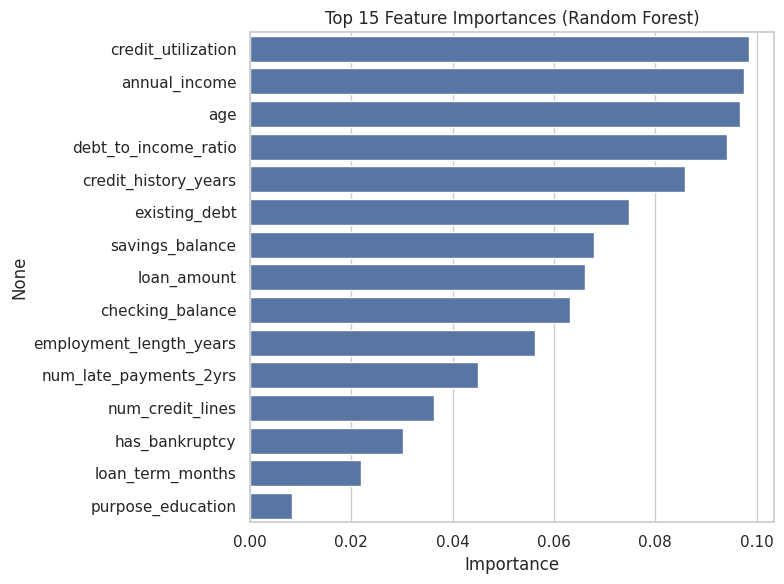

In [10]:
rf_pipeline = fitted_pipelines["Random Forest"]
rf = rf_pipeline.named_steps["classifier"]
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_names = numeric_features + cat_names

importances = pd.Series(rf.feature_importances_, index=all_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="#4C72B0")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

## 8. Save the Best Model

We select the model with the highest F1-score — a balanced metric that
matters more than raw accuracy on an imbalanced credit dataset like
this one (~74% good / 26% bad).

In [11]:
best_row = metrics_df.loc[metrics_df["f1_score"].idxmax()]
best_name = best_row["model"]
best_pipeline = fitted_pipelines[best_name]

joblib.dump(best_pipeline, "models/best_credit_scoring_model.joblib")
with open("outputs/best_model_info.json", "w") as f:
    json.dump(best_row.to_dict(), f, indent=2)

print(f"Best model: {best_name} (F1-score = {best_row['f1_score']:.4f})")
print("Saved to models/best_credit_scoring_model.joblib")

Best model: Random Forest (F1-score = 0.8559)
Saved to models/best_credit_scoring_model.joblib


## 9. Conclusion

All three models perform well above a random baseline. Random Forest
and Logistic Regression tie on F1-score, with Random Forest edging
ahead on ROC-AUC. Feature importance confirms **debt-to-income ratio**,
**credit utilization**, and **late-payment history** are the strongest
predictors of credit risk — consistent with real-world underwriting
practice. Logistic Regression is nearly as strong and far more
interpretable, a reasonable choice if explainability to a loan officer
or regulator matters more than a small accuracy gain.

To use this on real data, replace the dataset-generation cell (Step 1)
with code that loads a real credit dataset with a `creditworthy` target
column — everything downstream works unchanged.